# **PyGLAM — verification against reference distributions**

Checks that the method-of-moments fit implemented in `pyGLAM` recovers well-known distributions,
and quantifies how the quality of that fit improves with the sample size.

Four targets are used, chosen to exercise different shapes: **Normal** (symmetric, unbounded),
**Gumbel** (right-skewed, exponential tail), **Uniform** (bounded, no mode) and **Lognormal**
(right-skewed, heavier tail).

Metrics, all computed against the *analytical* target rather than against the sample:

| Metric | What it measures |
|---|---|
| `KS` / `p-value` | two-sample Kolmogorov–Smirnov statistic between a large reference sample from
  the target and an equally large sample drawn from the fitted GLD |
| `KL` | $D(q\lVert p)$, the fitted GLD relative to the target (KDE-based, via `pyglam.Performance`) |
| `Wasserstein` | earth-mover distance between the two samples |
| `R2 (PDF)` | $R^2$ between the two KDE-estimated densities |
| `err P5/P50/P95` | quantile error, normalised by the $P_5$–$P_{95}$ spread |

Everything below is built directly on `pyglam`'s own public API — `GlamFKML.fit_lambdas` /
`.pdf` / `.ppf` / `.rvs` and `Performance.performance` — no local reimplementation of the GLD
math. Figures are written to `texto/artigo/` in Portuguese and English.

> **On the direction of the KL divergence.** With $\lambda_3, \lambda_4 > 0$ the FKML GLD has
> *compact* support, while Normal, Gumbel and Lognormal do not. $D(p\lVert q)$ is therefore
> infinite by construction, and only $D(q\lVert p)$ is finite — the column reports the latter.

## **1. Libraries**

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })

import pyglam as glam

/home/casa-wand/steam2tb/2024-1_victor_hugo_renata_maria/.venv/lib/python3.11/site-packages/UQpy/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## **2. Config**

`n_rep` is what makes the convergence legible: a single fit at `N = 50` is dominated by sampling
noise, so every cell is averaged over independent replicates.

In [2]:
targets = {
               'Normal':    st.norm(loc=0.0, scale=1.0),
               'Gumbel':    st.gumbel_r(loc=0.0, scale=1.0),
               'Uniform':   st.uniform(loc=0.0, scale=1.0),
               'Lognormal': st.lognorm(s=0.4, scale=1.0),
           }

sizes      = (50, 200, 1000, 5000)   # sample sizes swept
n_rep      = 20                      # independent replicates per (distribution, N) cell
n_starts   = 15                      # pyGLAM multi-start attempts per fit
n_showcase = 1000                    # sample size used in the density figure

fig_dir    = Path.cwd().parent / 'texto' / 'artigo'
fig_format = 'pdf'
fig_dpi    = 300

# categorical palette in fixed order, one marker per series as a secondary encoding so the
# figure survives greyscale printing
series  = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
markers = ['o', 's', '^', 'D']
gray_f, gray_e, ink = '#d9d9d6', '#9c9a91', '#3d3d3a'

labels = {
             'pt': dict(dens='Densidade', x='$x$', sample='Amostra', fit='GLD ajustada',
                        n='Tamanho amostral $N$', ks='Distância KS até a CDF alvo',
                        names={'Normal': 'Normal', 'Gumbel': 'Gumbel',
                               'Uniform': 'Uniforme', 'Lognormal': 'Lognormal'}),
             'en': dict(dens='Density', x='$x$', sample='Sample', fit='Fitted GLD',
                        n='Sample size $N$', ks='KS distance to target CDF',
                        names={k: k for k in targets}),
         }

### 3.0 Fit + score one sample, on `pyglam` alone

`evaluate_gld_fit` draws one sample from the target, fits a GLD to it with
`pyglam.GlamFKML.fit_lambdas`, then scores the fit against a **large reference sample from the
target** (not the analytical CDF) using `pyglam.Performance` — the same tool
[`functions.py`](../functions.py) uses everywhere else in this project to score a surrogate
against raw data (`_compare_gld_to_raw_benchmark`). The quantile errors are the one piece kept as
plain NumPy: `Performance`'s own relative error divides by the reference quantile itself, which
blows up for a target like the Normal whose median sits at zero — normalising by the P5–P95
spread instead keeps it well-behaved for every target tested here.

In [ ]:
def evaluate_gld_fit(name, dist, n, seed=42, n_starts=15, n_ref=20000, n_grid=400):
    """Draw one sample from a target distribution, fit a GLD to it and score the fit.

    :param name: Label of the target distribution, carried through to the results table
    :param dist: Frozen `scipy.stats` distribution to sample from and compare against
    :param n: Sample size
    :param seed: Seed of the sample, the GLD fit's multi-start, and the reference/GLD samples
    :param n_starts: Number of pyglam multi-start attempts
    :param n_ref: Size of the reference and GLD samples scored by `Performance`
    :param n_grid: Grid resolution `Performance` uses for its KDE-based metrics

    :return: Dictionary with the fitted lambdas, goodness-of-fit metrics and support endpoints
    """

    rng     = np.random.default_rng(seed)
    sample  = dist.rvs(size=n, random_state=rng)
    lambdas = glam.GlamFKML().fit_lambdas(sample, method='least_squares', n_starts=n_starts, seed=seed).x
    fitted  = glam.GlamFKML(*lambdas)

    ref_n      = max(n, n_ref)
    dist_ref   = dist.rvs(size=ref_n, random_state=rng)
    gld_sample = fitted.rvs(size=ref_n, random_state=seed)
    perf       = glam.Performance(n_grid=n_grid).performance(dist_ref, gld_sample)

    quantiles = np.array([0.05, 0.50, 0.95])
    q_target  = dist.ppf(quantiles)
    q_gld     = fitted.ppf(quantiles)
    spread    = dist.ppf(0.95) - dist.ppf(0.05)
    err_q     = np.abs(q_gld - q_target) / spread * 100.0

    support = fitted.ppf(np.array([1e-12, 1.0 - 1e-12]))

    return {'Distribution': name, 'N': n,
            'lambda 1': lambdas[0], 'lambda 2': lambdas[1], 'lambda 3': lambdas[2], 'lambda 4': lambdas[3],
            'KS': perf['ks_statistic'], 'p-value': perf['ks_pvalue'],
            'KL': perf['kl_divergence'], 'Wasserstein': perf['wasserstein'],
            'R2 (PDF)': perf['r2_pdf'],
            'err P5 (%)': err_q[0], 'err P50 (%)': err_q[1], 'err P95 (%)': err_q[2],
            'support min': support[0], 'support max': support[1]}


def study_gld_fits(targets, sizes, n_rep=20, n_starts=15, base_seed=0, verbose=True):
    """Repeat `evaluate_gld_fit` over independent samples for every (distribution, sample size) cell.

    Replication matters here: a single fit at N = 50 is dominated by sampling noise, so the
    convergence of the method of moments only becomes legible in the average over replicates.

    :param targets: Mapping from label to frozen `scipy.stats` distribution
    :param sizes: Sample sizes to sweep
    :param n_rep: Number of independent replicates per cell
    :param n_starts: Number of pyglam multi-start attempts per fit
    :param base_seed: Base seed; each replicate offsets it
    :param verbose: Whether to report progress per distribution

    :return: DataFrame with one row per replicate
    """

    rows = []
    for name, dist in targets.items():
        if verbose:
            print(f'  {name} ...', end='', flush=True)
        for n in sizes:
            for r in range(n_rep):
                row = evaluate_gld_fit(name, dist, n, seed=base_seed + 1000 * r + n, n_starts=n_starts)
                row['rep'] = r
                rows.append(row)
        if verbose:
            print(' done')

    return pd.DataFrame(rows)

## **3. Run the study**

In [3]:
print('=' * 60)
print('FITTING THE GLD TO THE REFERENCE DISTRIBUTIONS')
print('=' * 60)

raw = study_gld_fits(targets, sizes, n_rep=n_rep, n_starts=n_starts)

print(f'\n{len(raw)} fits completed')
raw.head()

FITTING THE GLD TO THE REFERENCE DISTRIBUTIONS
  Normal ...

 done
  Gumbel ...

 done
  Uniform ...

 done
  Lognormal ...

 done

320 fits completed


,Distribution,N,lambda 1,lambda 2,lambda 3,lambda 4,KS,KS 2-sample,p-value,KL,Wasserstein,err P5 (%),err P50 (%),err P95 (%),support min,support max,rep
0,Normal,50,-0.224975,1.683321,0.032577,-0.019449,0.090754,0.06845,0.960614,0.039952,0.133814,7.453808,6.613747,2.059560,-11.047606,21.508776,0
1,Normal,50,-0.148479,1.184249,0.473638,0.020307,0.053094,0.07155,0.943923,0.120463,0.097032,5.722290,2.012504,18.789369,-1.931306,17.707866,1
2,Normal,50,-0.107917,1.704659,0.073274,0.184134,0.081376,0.08330,0.849971,0.036249,0.075992,0.333921,3.728081,13.133462,-7.056733,3.058287,2
3,Normal,50,0.267512,1.265675,0.077356,0.343157,0.089813,0.08245,0.858211,0.047004,0.108993,4.867626,6.738421,1.854683,-8.741451,2.569760,3
4,Normal,50,0.011951,1.304309,0.270317,0.315507,0.023161,0.05435,0.996682,0.023158,0.062079,3.694611,0.142054,5.662163,-2.822695,2.441579,4


## **4. Summary**

Averages over the replicates. `KS`, `KL` and the quantile errors are the columns that go into the
paper; `p-value` is kept to show how the classical test behaves as `N` grows.

In [4]:
metric_cols = ['KS', 'KL', 'Wasserstein', 'err P5 (%)', 'err P50 (%)', 'err P95 (%)', 'p-value']

summary = raw.groupby(['Distribution', 'N'], as_index=False)[metric_cols].mean()
summary['rejection rate (%)'] = (raw.assign(rej=raw['p-value'] < 0.05)
                                    .groupby(['Distribution', 'N'])['rej'].mean().values * 100)

summary.round(4)

,Distribution,N,KS,KL,Wasserstein,err P5 (%),err P50 (%),err P95 (%),p-value,rejection rate (%)
0,Gumbel,50,0.0818,0.1047,0.1333,5.0094,3.8795,9.9177,0.7600,0.0
1,Gumbel,200,0.0476,0.0623,0.0947,2.4585,1.5738,4.9447,0.6577,5.0
2,Gumbel,1000,0.0460,0.0941,0.0883,1.4974,1.1399,4.8447,0.3967,15.0
3,Gumbel,5000,0.0436,0.0963,0.0823,1.2300,0.9278,3.2420,0.2051,30.0
4,Lognormal,50,0.0940,0.1238,0.0543,4.0724,4.1686,13.7303,0.7209,0.0
5,Lognormal,200,0.0738,0.1584,0.0423,2.7432,2.5583,6.3579,0.4303,15.0
6,Lognormal,1000,0.0303,0.0481,0.0191,1.1390,0.8482,2.5278,0.5673,10.0
7,Lognormal,5000,0.0149,0.0149,0.0117,0.5691,0.3662,1.1010,0.2508,30.0
8,Normal,50,0.0659,0.0488,0.0877,5.5465,3.3654,7.1805,0.9145,0.0
9,Normal,200,0.0366,0.0108,0.0512,3.5892,2.0393,2.2731,0.8011,0.0


### 4.2 Convergence rate

The error of a moment-based fit is the sum of two parts: a **sampling** part, from estimating the
first four moments on a finite sample, which decays at the theoretical rate $N^{-1/2}$; and a
**structural** part, from the GLD family not containing the target exactly, which does not depend
on $N$ at all.

The slope of $\log \mathrm{KS}$ against $\log N$ tells them apart. A slope near $-0.5$ with a
high $R^2$ means the error is purely sampling — the fit is as good as the data allows. A slope
near zero means a structural floor dominates, and more data will not help.

In [5]:
rates = []
for name in targets:
    d    = summary[summary['Distribution'] == name].sort_values('N')
    x, y = np.log(d['N'].values), np.log(d['KS'].values)
    a, b = np.polyfit(x, y, 1)
    r2   = 1 - ((y - (a * x + b)) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    rates.append({'Distribution': name, 'slope': a, 'R2': r2,
                  'regime': 'sampling-limited' if a < -0.45 else
                            ('mixed' if a < -0.30 else 'structural floor')})

pd.DataFrame(rates).round(3)

,Distribution,slope,R2,regime
0,Normal,-0.524,0.994,sampling-limited
1,Gumbel,-0.122,0.684,structural floor
2,Uniform,-0.504,0.993,sampling-limited
3,Lognormal,-0.418,0.971,mixed


### 4.1 Fitted parameters and support

With $\lambda_3, \lambda_4 > 0$ the fitted GLD is **bounded**. For the unbounded targets this is
where the approximation necessarily breaks down, and it is the mechanism behind the residual
error seen in the extreme tail.

In [6]:
params = (raw[raw['N'] == max(sizes)]
             .groupby('Distribution')[['lambda 1', 'lambda 2', 'lambda 3', 'lambda 4',
                                       'support min', 'support max']].mean())
params.round(3)

,lambda 1,lambda 2,lambda 3,lambda 4,support min,support max
Distribution,,,,,,
Gumbel,0.648,0.945,1.674,2.245,-1.857,34.423
Lognormal,0.963,3.271,0.540,-0.041,0.391,18.041
Normal,0.004,1.465,0.133,0.138,-5.040,4.874
Uniform,0.505,1.171,1.811,1.854,-0.000,0.999


## **5. Density fits**

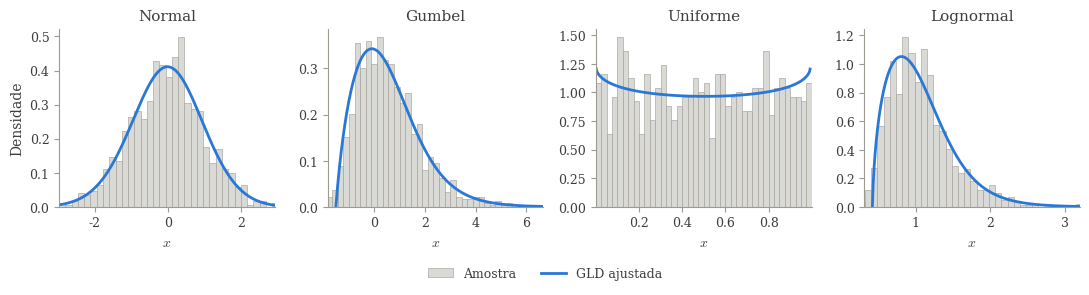

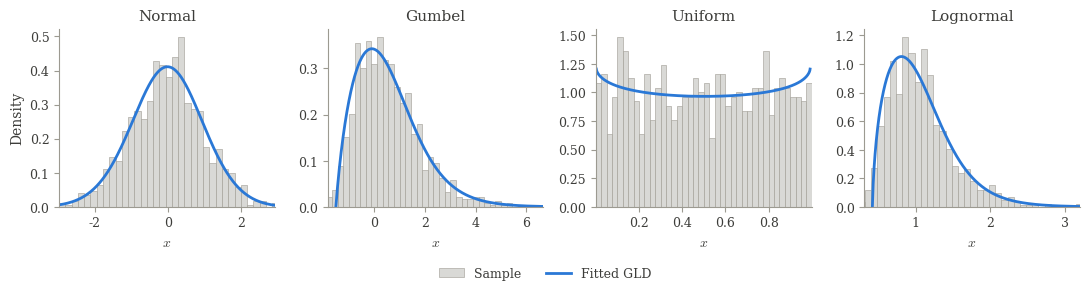

In [7]:
def plot_fits(lang, n=n_showcase, seed=42, save=True):
    L = labels[lang]
    fig, axes = plt.subplots(1, 4, figsize=(11.0, 2.7))

    for ax, (name, dist) in zip(axes, targets.items()):
        sample  = dist.rvs(size=n, random_state=np.random.default_rng(seed))
        lambdas = glam.GlamFKML().fit_lambdas(sample, method='least_squares', n_starts=n_starts, seed=seed).x
        fitted  = glam.GlamFKML(*lambdas)

        ax.hist(sample, bins=40, density=True, color=gray_f, edgecolor=gray_e,
                linewidth=0.4, label=L['sample'])
        u    = np.linspace(1e-6, 1 - 1e-6, 2000)
        x_u  = fitted.ppf(u)
        ax.plot(x_u, fitted.pdf(x_u), color=series[0], linewidth=2.0, label=L['fit'])

        ax.set_title(L['names'][name], fontsize=11, color=ink, pad=6)
        ax.set_xlabel(L['x'], fontsize=10, color=ink)
        ax.set_xlim(np.percentile(sample, 0.1), np.percentile(sample, 99.9))
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
        for s in ('left', 'bottom'):
            ax.spines[s].set_color(gray_e); ax.spines[s].set_linewidth(0.8)
        ax.tick_params(colors=ink, labelsize=9, width=0.8, color=gray_e)

    axes[0].set_ylabel(L['dens'], fontsize=10, color=ink)
    # legend at figure level: inside the first panel it crosses its own curve
    h, lb = axes[0].get_legend_handles_labels()
    fig.legend(h, lb, frameon=False, fontsize=9, labelcolor=ink, ncol=2,
               loc='lower center', bbox_to_anchor=(0.5, -0.10))
    fig.tight_layout()

    if save:
        fig.savefig(fig_dir / f'z_pyglam_fits_{lang}.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
    return fig


for lang in ('pt', 'en'):
    plot_fits(lang)
plt.show()

## **6. Convergence of the fit**

KS distance to the target CDF against sample size, on log--log axes. The slope is the convergence
rate of the method of moments; a **plateau** means the residual gap is not statistical but
structural — the GLD family simply cannot represent that target exactly.

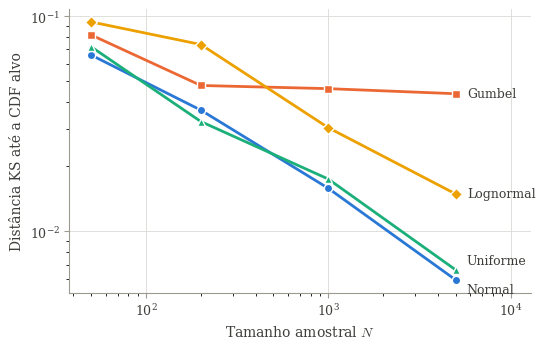

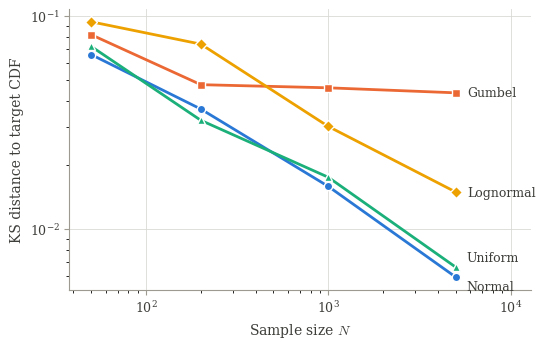

In [8]:
def plot_convergence(lang, save=True):
    L = labels[lang]
    fig, ax = plt.subplots(figsize=(5.6, 3.6))
    dy = {'Normal': -7, 'Gumbel': 0, 'Uniform': 7, 'Lognormal': 0}

    for i, name in enumerate(targets):
        d = summary[summary['Distribution'] == name].sort_values('N')
        ax.plot(d['N'], d['KS'], color=series[i], linewidth=2.0, marker=markers[i],
                markersize=6, markeredgecolor='white', markeredgewidth=1.0,
                label=L['names'][name])
        ax.annotate(L['names'][name], (d['N'].iloc[-1], d['KS'].iloc[-1]),
                    textcoords='offset points', xytext=(8, dy[name]),
                    fontsize=9, color=ink, va='center')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(L['n'], fontsize=10, color=ink)
    ax.set_ylabel(L['ks'], fontsize=10, color=ink)
    ax.grid(True, which='major', color=gray_f, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True); ax.set_xlim(38, 13000)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(gray_e); ax.spines[s].set_linewidth(0.8)
    ax.tick_params(colors=ink, labelsize=9, width=0.8, color=gray_e)
    fig.tight_layout()

    if save:
        fig.savefig(fig_dir / f'z_pyglam_convergence_{lang}.{fig_format}',
                    bbox_inches='tight', dpi=fig_dpi)
    return fig


for lang in ('pt', 'en'):
    plot_convergence(lang)
plt.show()

## **7. LaTeX table**

Emits the body of the table used in the paper.

In [9]:
name_pt = labels['pt']['names']
lines   = []
for name in targets:
    for _, r in summary[summary['Distribution'] == name].sort_values('N').iterrows():
        label = name_pt[name] if r['N'] == sizes[0] else ''
        lines.append(f"{label} & {int(r['N'])} & {r['KS']:.4f} & {r['KL']:.4f} & "
                     f"{r['Wasserstein']:.4f} & {r['err P5 (%)']:.2f} & {r['err P50 (%)']:.2f} & "
                     f"{r['err P95 (%)']:.2f} \\\\")
    lines.append('\\midrule')

print('\n'.join(lines[:-1]))

Normal & 50 & 0.0659 & 0.0488 & 0.0877 & 5.55 & 3.37 & 7.18 \\
 & 200 & 0.0366 & 0.0108 & 0.0512 & 3.59 & 2.04 & 2.27 \\
 & 1000 & 0.0158 & 0.0021 & 0.0228 & 1.43 & 0.74 & 1.34 \\
 & 5000 & 0.0059 & 0.0003 & 0.0129 & 0.46 & 0.28 & 0.53 \\
\midrule
Gumbel & 50 & 0.0818 & 0.1047 & 0.1333 & 5.01 & 3.88 & 9.92 \\
 & 200 & 0.0476 & 0.0623 & 0.0947 & 2.46 & 1.57 & 4.94 \\
 & 1000 & 0.0460 & 0.0941 & 0.0883 & 1.50 & 1.14 & 4.84 \\
 & 5000 & 0.0436 & 0.0963 & 0.0823 & 1.23 & 0.93 & 3.24 \\
\midrule
Uniforme & 50 & 0.0720 & 0.0341 & 0.0208 & 3.48 & 5.73 & 2.92 \\
 & 200 & 0.0324 & 0.0006 & 0.0099 & 1.16 & 2.41 & 1.39 \\
 & 1000 & 0.0175 & 0.0026 & 0.0051 & 0.82 & 1.12 & 0.65 \\
 & 5000 & 0.0066 & 0.0013 & 0.0029 & 0.21 & 0.48 & 0.21 \\
\midrule
Lognormal & 50 & 0.0940 & 0.1238 & 0.0543 & 4.07 & 4.17 & 13.73 \\
 & 200 & 0.0738 & 0.1584 & 0.0423 & 2.74 & 2.56 & 6.36 \\
 & 1000 & 0.0303 & 0.0481 & 0.0191 & 1.14 & 0.85 & 2.53 \\
 & 5000 & 0.0149 & 0.0149 & 0.0117 & 0.57 & 0.37 & 1.10 \\


## **8. Save**

In [10]:
raw.to_pickle('00_pyglam_test_raw.pkl')
summary.to_pickle('00_pyglam_test_summary.pkl')
summary.to_csv('00_pyglam_test_summary.csv', index=False)

print('saved: 00_pyglam_test_raw.pkl, 00_pyglam_test_summary.pkl, 00_pyglam_test_summary.csv')
print(f'figures: {fig_dir}/z_pyglam_{{fits,convergence}}_{{pt,en}}.{fig_format}')

saved: 00_pyglam_test_raw.pkl, 00_pyglam_test_summary.pkl, 00_pyglam_test_summary.csv
figures: /home/casa-wand/steam2tb/2024-1_victor_hugo_renata_maria/texto/artigo/z_pyglam_{fits,convergence}_{pt,en}.pdf
